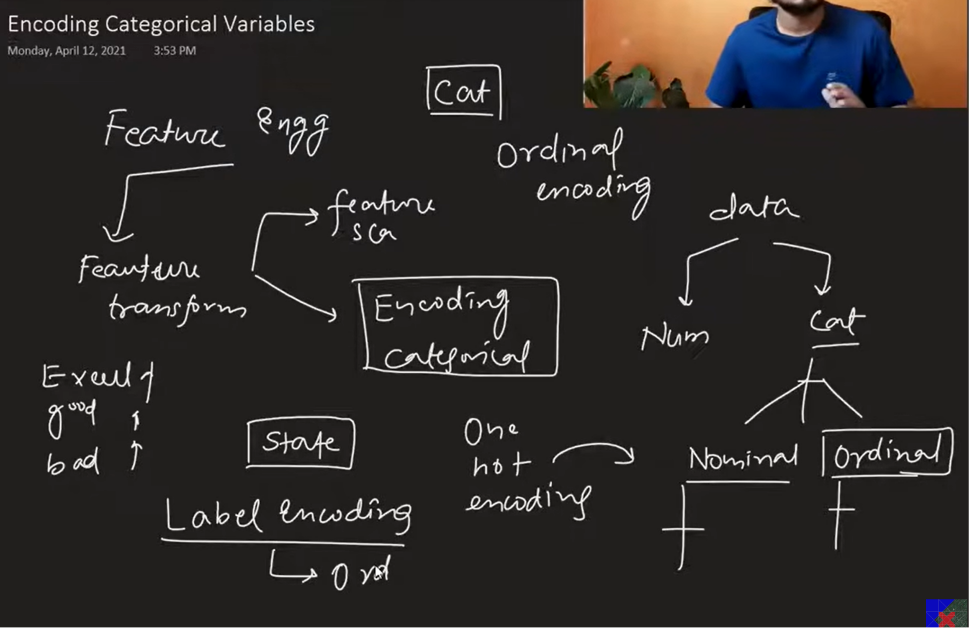

data is of two type 1.numerical 2. categorical 

there are twoo types of categorical data 
1. nominal 2.ordinal

`nominal`- there is no relation or order or values between the categories

example-- states name (there is not relation ) or enginerring_branch(cse , it ete therer is no relation or order that which have high values)

`ordinal`- there is a relation or order between the category 
example- reviews(excellent, good,badd) here excellent have greater value than good and bad , good have greated value then bad  

0r class section based on marks




there are two types of encoding 
1. ordinal encoding   2. one-hot encoding(for nominal data)


and the 3rd one is `label encoding ` which is similr to ordinal encoding 


as `ordinal encoding` is used when tthe categorical data in input column adn `label encoding` is used when the categorical data is in output column

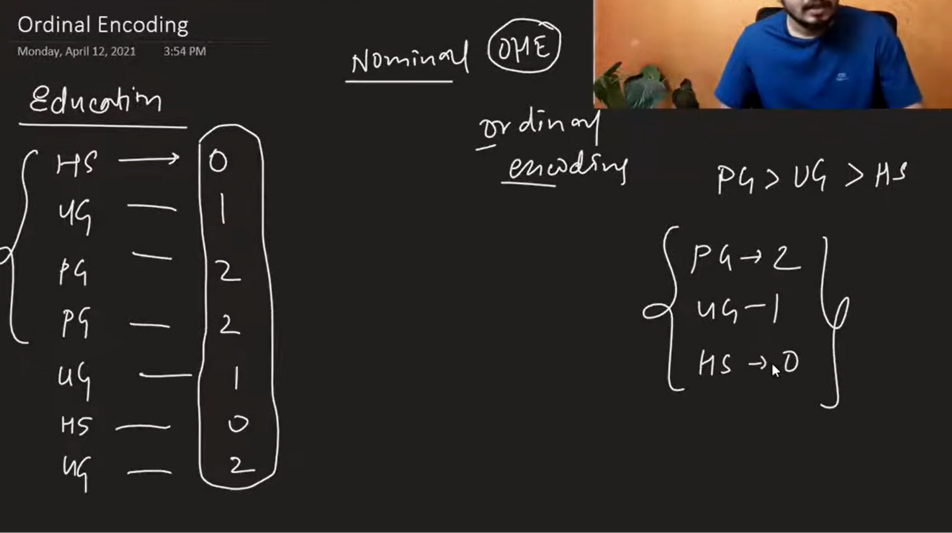

In [2]:
import numpy as np
import pandas as pd


In [3]:
df=pd.read_csv('dataset/customer.csv')

In [4]:
df.columns

Index(['age', 'gender', 'review', 'education', 'purchased'], dtype='object')

here gender,review,education and purchased all are categorical data and here review education and purchased are ordinal data

lets use only review,education and purchased dataset for our practice

In [5]:
df=df.iloc[:,2:]

In [6]:
df.columns

Index(['review', 'education', 'purchased'], dtype='object')

In [7]:
df.sample(4)

,review,education,purchased
17,Poor,UG,Yes
29,Average,UG,Yes
28,Poor,School,No
31,Poor,School,Yes


In [8]:
# split our dataframe
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(df.drop('purchased',axis=1),
                                                df['purchased'],
                                                test_size=0.2,
                                                random_state=0
                                                )

In [9]:
x_train.head(10)

,review,education
33,Good,PG
35,Poor,School
26,Poor,PG
34,Average,School
18,Good,School
7,Poor,School
14,Poor,PG
45,Poor,PG
48,Good,UG
29,Average,UG


In [15]:
# lets  apply ordinal encode

from sklearn.preprocessing import OrdinalEncoder

oe=OrdinalEncoder(categories=[['Poor','Average','Good'],['School','UG','PG']])


oe.fit(x_train)

x_train_encode=oe.transform(x_train)
x_test_enocde=oe.transform(x_test)

In [24]:
oe.categories_

[array(['Poor', 'Average', 'Good'], dtype=object),
 array(['School', 'UG', 'PG'], dtype=object)]

### Label encoding  (only for targeted column means output column)

In [20]:
from sklearn.preprocessing import LabelEncoder


Le=LabelEncoder()

Le.fit(y_train)

y_train_encode=Le.transform(y_train)
y_test_encode=Le.transform(y_test)

In [22]:
y_train_encode

array([1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0])

In [25]:
Le.classes_

array(['No', 'Yes'], dtype=object)